# Movie Genre Evolution Analyzer — Exploratory Data Analysis
This notebook explores the feature-engineered movie dataset to identify
patterns in movie production, genre distribution, ratings, runtime,
popularity, and their evolution over time.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load feature-engineered dataset
df = pd.read_csv("../data/processed/movies_feature_engineered.csv")

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (569655, 46)


## 1. Basic Dataset Overview

Before performing detailed analysis, we inspect the structure,
data types, and overall statistics of the feature-engineered dataset.

In [7]:
print("Dataset shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nFirst 5 rows:")
display(df.head())

Dataset shape: (569655, 46)

Columns:
['tconst', 'titleType', 'primaryTitle', 'startYear', 'runtimeMinutes', 'genres', 'genre_list', 'averageRating', 'numVotes', 'year', 'decade', 'era', 'movie_age', 'genre_count', 'genre_action', 'genre_adult', 'genre_adventure', 'genre_animation', 'genre_biography', 'genre_comedy', 'genre_crime', 'genre_documentary', 'genre_drama', 'genre_family', 'genre_fantasy', 'genre_film_noir', 'genre_game_show', 'genre_history', 'genre_horror', 'genre_music', 'genre_musical', 'genre_mystery', 'genre_news', 'genre_reality_tv', 'genre_romance', 'genre_sci_fi', 'genre_sport', 'genre_talk_show', 'genre_thriller', 'genre_war', 'genre_western', 'runtime_category', 'rating_category', 'log_votes', 'popularity_category', 'rating_popularity_score']

Data types:
tconst                      object
titleType                   object
primaryTitle                object
startYear                    int64
runtimeMinutes             float64
genres                      object
gen

,tconst,titleType,primaryTitle,startYear,runtimeMinutes,genres,genre_list,averageRating,numVotes,year,...,genre_sport,genre_talk_show,genre_thriller,genre_war,genre_western,runtime_category,rating_category,log_votes,popularity_category,rating_popularity_score
0,tt0000574,movie,The Story of the Kelly Gang,1906,70.0,"Action,Adventure,Biography","['Action', 'Adventure', 'Biography']",6.0,1084.0,1906,...,0,0,0,0,0,Short,Average,6.989335,Popular,41.936012
1,tt0000591,movie,The Prodigal Son,1907,90.0,Drama,['Drama'],4.8,40.0,1907,...,0,0,0,0,0,Medium,Low,3.713572,Low,17.825146
2,tt0000615,movie,Robbery Under Arms,1907,NaN,Drama,['Drama'],3.4,36.0,1907,...,0,0,0,0,0,Unknown,Low,3.610918,Low,12.277121
3,tt0000630,movie,Hamlet,1908,NaN,Drama,['Drama'],3.0,42.0,1908,...,0,0,0,0,0,Unknown,Low,3.761200,Low,11.283600
4,tt0000675,movie,Don Quijote,1908,NaN,Drama,['Drama'],3.8,32.0,1908,...,0,0,0,0,0,Unknown,Low,3.496508,Low,13.286729


## 2. Missing-value overview

In [21]:
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Columns with missing values:")
print(missing)

Columns with missing values:
averageRating              231990
numVotes                   231990
log_votes                  231990
rating_popularity_score    231990
runtimeMinutes             128235
dtype: int64


In [22]:
missing_pct = (df.isna().sum() / len(df) * 100)
missing_summary = pd.DataFrame({
    "Missing_Count": df.isna().sum(),
    "Missing_Percentage": missing_pct
})
missing_summary = missing_summary[
    missing_summary["Missing_Count"] > 0
].sort_values("Missing_Count", ascending=False)

display(missing_summary)

,Missing_Count,Missing_Percentage
averageRating,231990,40.724649
numVotes,231990,40.724649
log_votes,231990,40.724649
rating_popularity_score,231990,40.724649
runtimeMinutes,128235,22.510993


## 3. Movie Production Over Time

We analyze the number of movies released in each year to understand
how movie production has changed throughout cinematic history.

In [10]:
movies_per_year = (
    df.groupby("year")
      .size()
      .reset_index(name="movie_count")
)
display(movies_per_year.head(20))

,year,movie_count
0,1900,6
1,1901,8
2,1902,3
3,1903,4
4,1904,3
5,1905,13
6,1906,17
7,1907,11
8,1908,10
9,1909,31


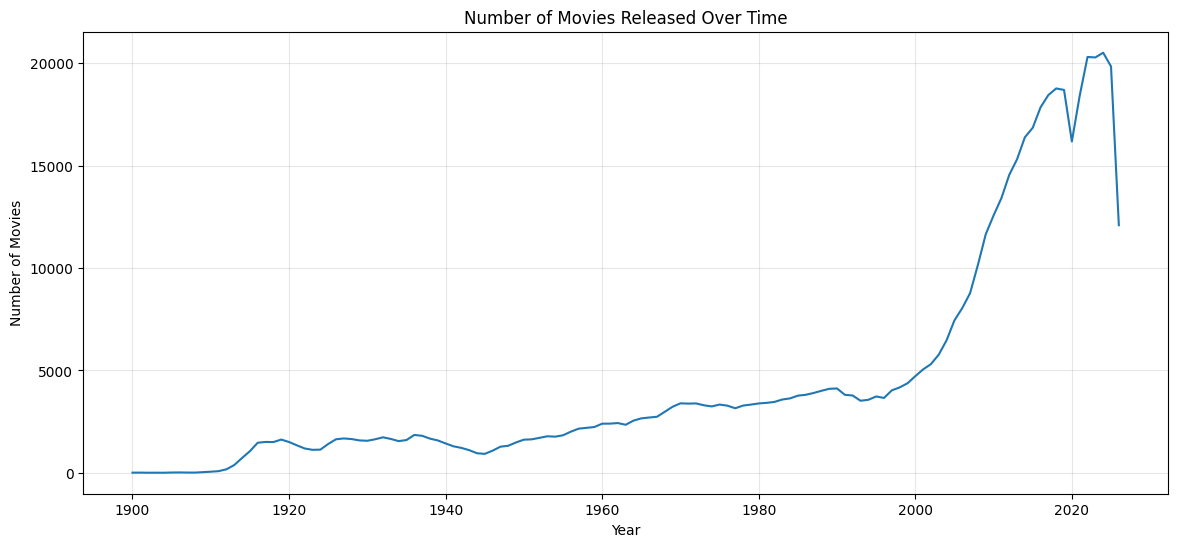

In [ ]:
plt.figure(figsize=(14, 6))

plt.plot(
    movies_per_year["year"],
    movies_per_year["movie_count"]
)
plt.title("Number of Movies Released Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Movies")
plt.grid(alpha=0.3)
plt.show()

In [12]:
movies_per_decade = (
    df.groupby("decade")
      .size()
      .reset_index(name="movie_count")
      .sort_values("decade")
)
display(movies_per_decade)

,decade,movie_count
0,1900,106
1,1910,8554
2,1920,14229
3,1930,16634
4,1940,12084
5,1950,18928
6,1960,26417
7,1970,33067
8,1980,37045
9,1990,38731


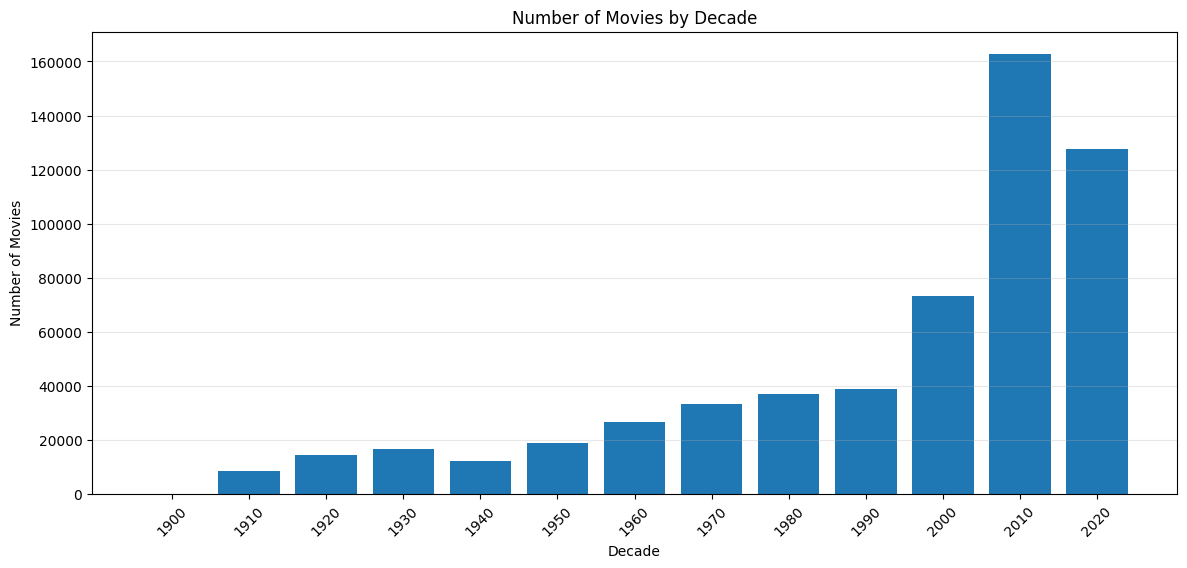

In [13]:
plt.figure(figsize=(14, 6))
plt.bar(
    movies_per_decade["decade"].astype(str),
    movies_per_decade["movie_count"]
)
plt.title("Number of Movies by Decade")
plt.xlabel("Decade")
plt.ylabel("Number of Movies")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.show()

## 4. Genre Analysis

Genre information is stored as a list for each movie.
We convert the stored genre lists into individual genres
before analyzing genre distribution.

In [23]:
import ast

In [24]:
genre_df = df[
    ["primaryTitle", "year", "decade", "genre_list"]
].copy()

genre_df["genre_list"] = genre_df["genre_list"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

display(genre_df.head())

,primaryTitle,year,decade,genre_list
0,The Story of the Kelly Gang,1906,1900,"[Action, Adventure, Biography]"
1,The Prodigal Son,1907,1900,[Drama]
2,Robbery Under Arms,1907,1900,[Drama]
3,Hamlet,1908,1900,[Drama]
4,Don Quijote,1908,1900,[Drama]


In [25]:
genre_df = genre_df.explode("genre_list")
genre_df = genre_df.rename(
    columns={"genre_list": "genre"}
)
genre_df = genre_df.dropna(subset=["genre"])

print("Rows after exploding genres:", len(genre_df))

display(genre_df.head(10))

Rows after exploding genres: 889641


,primaryTitle,year,decade,genre
0,The Story of the Kelly Gang,1906,1900,Action
0,The Story of the Kelly Gang,1906,1900,Adventure
0,The Story of the Kelly Gang,1906,1900,Biography
1,The Prodigal Son,1907,1900,Drama
2,Robbery Under Arms,1907,1900,Drama
3,Hamlet,1908,1900,Drama
4,Don Quijote,1908,1900,Drama
5,The Fairylogue and Radio-Plays,1908,1900,Adventure
5,The Fairylogue and Radio-Plays,1908,1900,Fantasy
6,"Hamlet, Prince of Denmark",1910,1910,Drama


In [ ]:
genre_counts = (
    genre_df["genre"]
    .value_counts()
    .reset_index()
)
genre_counts.columns = ["genre", "movie_count"]
display(genre_counts)

,genre,movie_count
0,Drama,240101
1,Documentary,139858
2,Comedy,109361
3,Action,49704
4,Romance,49304
5,Crime,38141
6,Thriller,37977
7,Horror,34077
8,Adventure,26762
9,Family,17923


<BarContainer object of 27 artists>

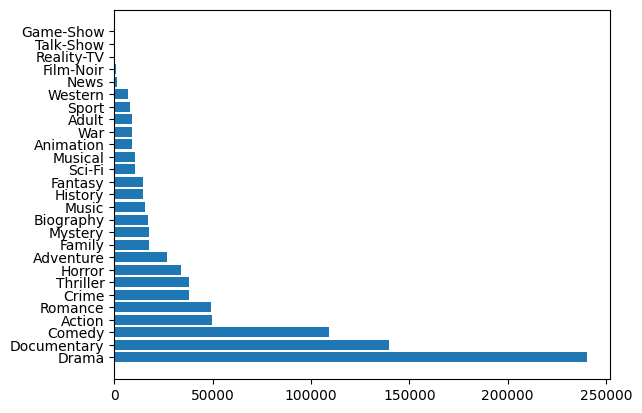

In [27]:
plt.barh(
    genre_counts["genre"],
    genre_counts["movie_count"]
)

In [28]:
top_genres = genre_counts.head(20)
display(top_genres)

,genre,movie_count
0,Drama,240101
1,Documentary,139858
2,Comedy,109361
3,Action,49704
4,Romance,49304
5,Crime,38141
6,Thriller,37977
7,Horror,34077
8,Adventure,26762
9,Family,17923


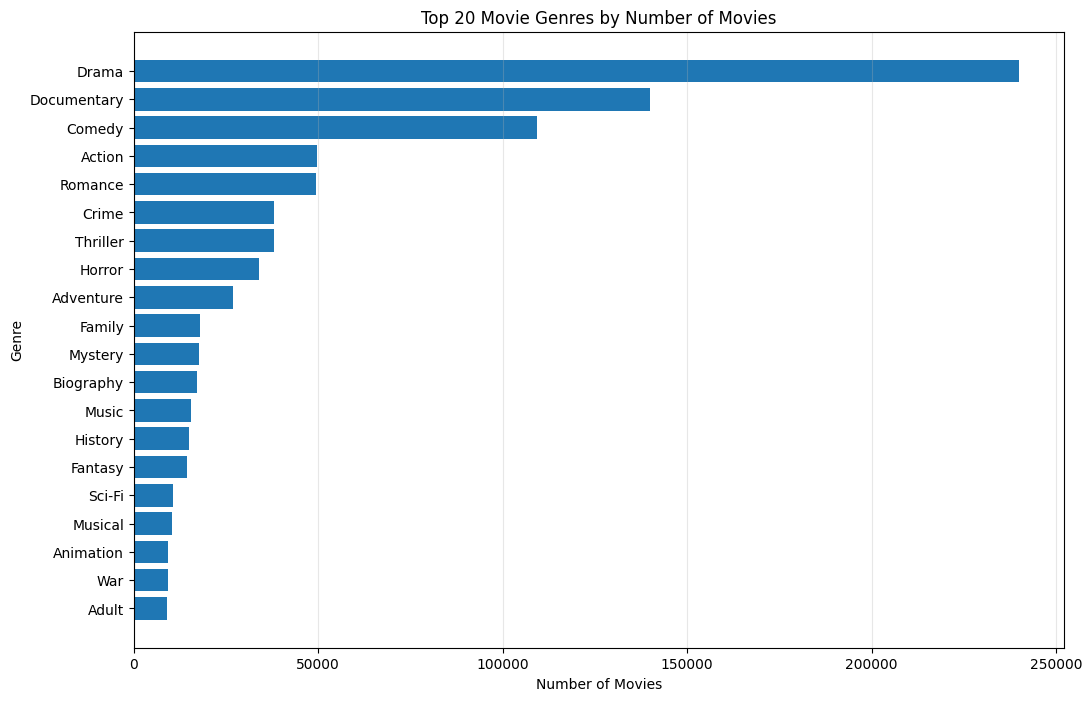

In [29]:
plt.figure(figsize=(12, 8))
plt.barh(
    top_genres["genre"],
    top_genres["movie_count"]
)
plt.title("Top 20 Movie Genres by Number of Movies")
plt.xlabel("Number of Movies")
plt.ylabel("Genre")
plt.gca().invert_yaxis()
plt.grid(axis="x", alpha=0.3)
plt.show()

## 5. Genre Evolution Over Time

This section analyzes how movie genres have changed in popularity
across different decades. This helps identify long-term trends
and shifts in audience and production preferences.

In [30]:
genre_decade_counts = (
    genre_df
    .groupby(["decade", "genre"])
    .size()
    .reset_index(name="movie_count")
)
display(genre_decade_counts.head(20))

,decade,genre,movie_count
0,1900,Action,2
1,1900,Adventure,3
2,1900,Biography,4
3,1900,Comedy,6
4,1900,Documentary,71
5,1900,Drama,20
6,1900,Family,1
7,1900,Fantasy,2
8,1900,History,3
9,1900,Horror,1


In [ ]:
selected_genres = [
    "Drama",
    "Comedy",
    "Documentary",
    "Action",
    "Romance",
    "Crime",
    "Thriller",
    "Horror",
    "Adventure",
    "Fantasy"
]
genre_trends = genre_decade_counts[
    genre_decade_counts["genre"].isin(selected_genres)
].copy()

display(genre_trends.head(20))

,decade,genre,movie_count
0,1900,Action,2
1,1900,Adventure,3
3,1900,Comedy,6
4,1900,Documentary,71
5,1900,Drama,20
7,1900,Fantasy,2
9,1900,Horror,1
13,1900,Romance,1
16,1910,Action,242
17,1910,Adventure,344


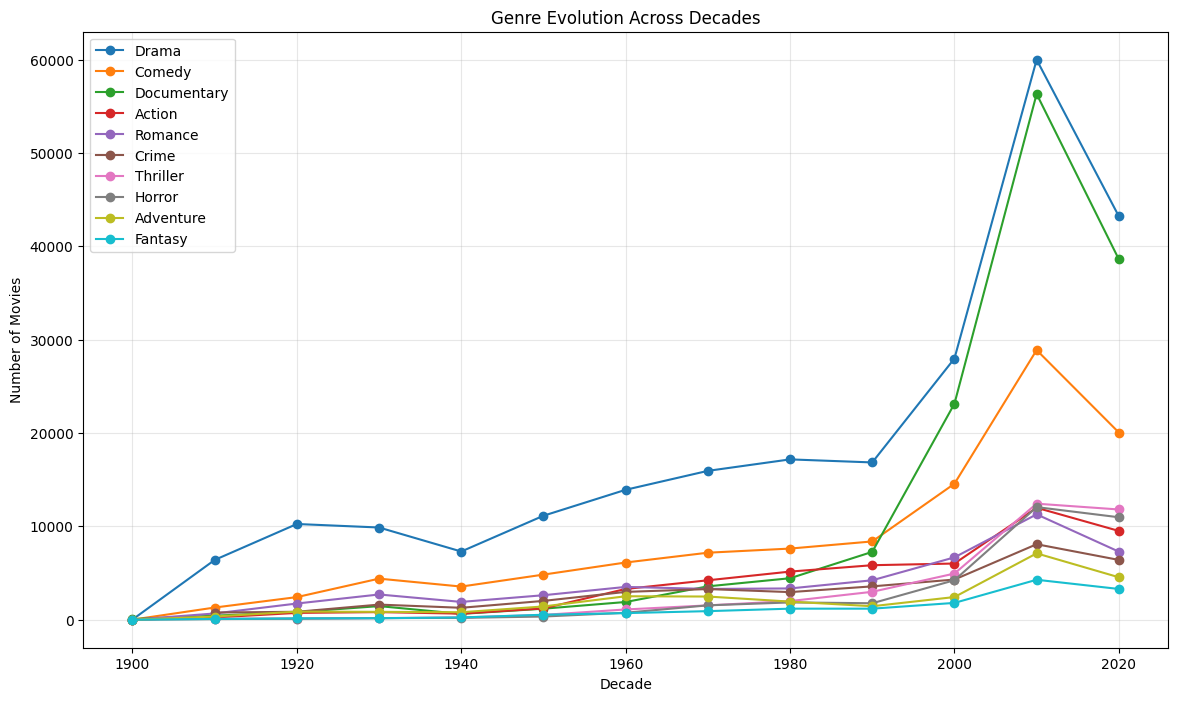

In [32]:
plt.figure(figsize=(14, 8))
for genre in selected_genres:
    genre_data = genre_trends[
        genre_trends["genre"] == genre
    ]
    plt.plot(
        genre_data["decade"],
        genre_data["movie_count"],
        marker="o",
        label=genre
    )
plt.title("Genre Evolution Across Decades")
plt.xlabel("Decade")
plt.ylabel("Number of Movies")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [33]:
dominant_genre_by_decade = (
    genre_decade_counts
    .sort_values(
        ["decade", "movie_count"],
        ascending=[True, False]
    )
    .groupby("decade")
    .first()
    .reset_index()
)
dominant_genre_by_decade = dominant_genre_by_decade[
    ["decade", "genre", "movie_count"]
]

display(dominant_genre_by_decade)

,decade,genre,movie_count
0,1900,Documentary,71
1,1910,Drama,6404
2,1920,Drama,10256
3,1930,Drama,9880
4,1940,Drama,7308
5,1950,Drama,11141
6,1960,Drama,13920
7,1970,Drama,15948
8,1980,Drama,17177
9,1990,Drama,16851


### Key Insight

The dominant genre varies across different periods of cinema history.
Comparing genre counts across decades reveals how movie production
preferences have changed over time.

## 6. Ratings Analysis

This section analyzes the distribution of movie ratings and examines
how ratings and audience voting activity vary across movies.

In [34]:
display(df[["averageRating", "numVotes"]].describe())

,averageRating,numVotes
count,337665.000000,3.376650e+05
mean,6.133446,3.822306e+03
std,1.374148,3.864066e+04
min,1.000000,5.000000e+00
25%,5.300000,2.100000e+01
50%,6.200000,6.900000e+01
75%,7.100000,3.450000e+02
max,10.000000,3.226746e+06


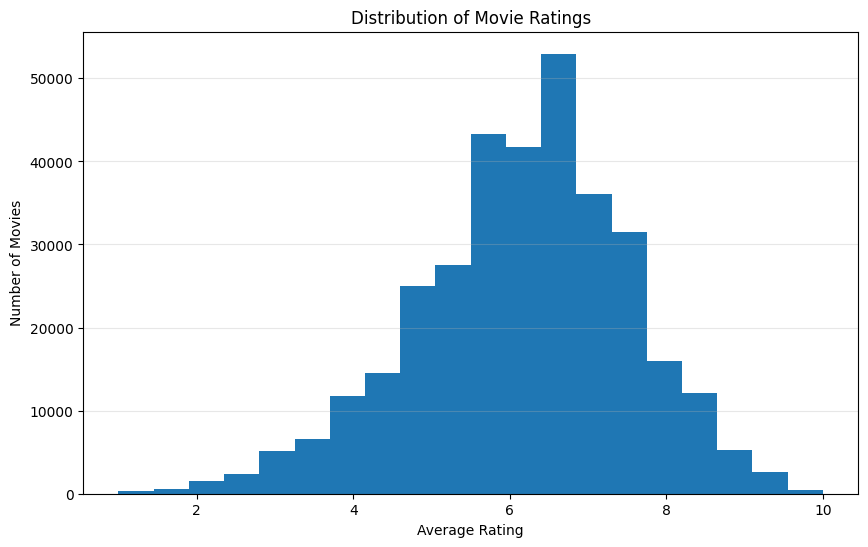

In [35]:
plt.figure(figsize=(10, 6))
plt.hist(
    df["averageRating"],
    bins=20
)
plt.title("Distribution of Movie Ratings")
plt.xlabel("Average Rating")
plt.ylabel("Number of Movies")
plt.grid(axis="y", alpha=0.3)

plt.show()

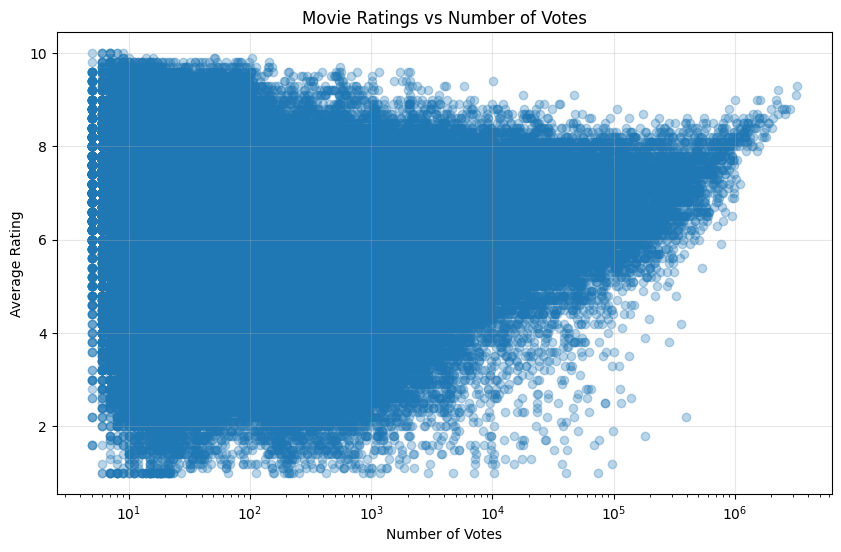

In [36]:
plt.figure(figsize=(10, 6))
plt.scatter(
    df["numVotes"],
    df["averageRating"],
    alpha=0.3
)
plt.title("Movie Ratings vs Number of Votes")
plt.xlabel("Number of Votes")
plt.ylabel("Average Rating")
plt.xscale("log")
plt.grid(alpha=0.3)
plt.show()

In [37]:
rating_vote_corr = df[["averageRating", "numVotes"]].corr()

display(rating_vote_corr)

,averageRating,numVotes
averageRating,1.000000,0.062778
numVotes,0.062778,1.000000


### Key Insight

The correlation between average movie rating and number of votes is approximately **0.063**, indicating a very weak positive relationship. This suggests that audience voting activity does not strongly determine movie ratings. Movies with a large number of votes are not necessarily rated significantly higher than movies with fewer votes.

## 7. Movie Production Trends Over Time

This section analyzes how movie production has changed across different decades. It helps identify the growth of the film industry and major changes in movie production volume over time.

In [38]:
decade_counts = (
    df["decade"]
    .value_counts()
    .sort_index()
    .reset_index()
)
decade_counts.columns = ["decade", "movie_count"]

display(decade_counts)

,decade,movie_count
0,1900,106
1,1910,8554
2,1920,14229
3,1930,16634
4,1940,12084
5,1950,18928
6,1960,26417
7,1970,33067
8,1980,37045
9,1990,38731


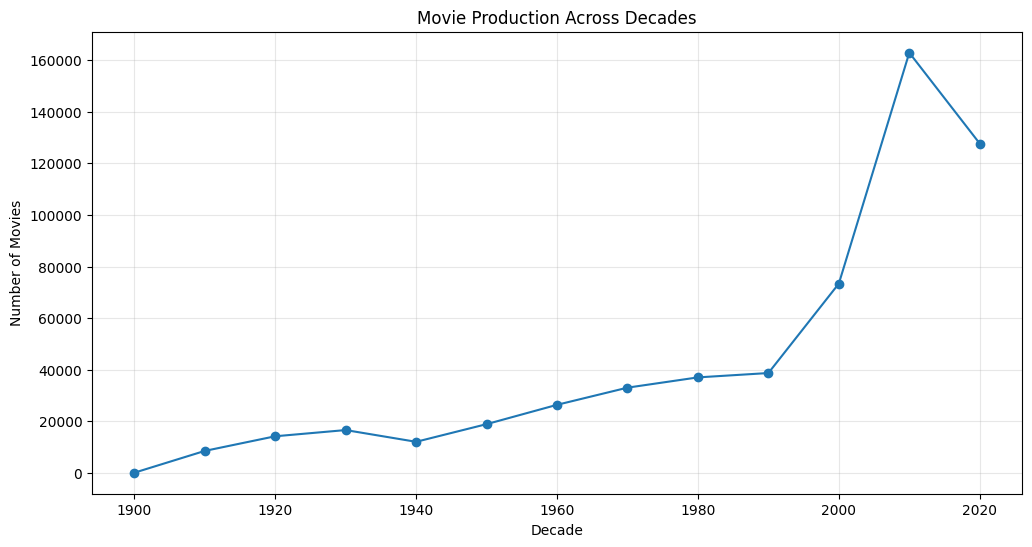

In [39]:
plt.figure(figsize=(12, 6))
plt.plot(
    decade_counts["decade"],
    decade_counts["movie_count"],
    marker="o"
)
plt.title("Movie Production Across Decades")
plt.xlabel("Decade")
plt.ylabel("Number of Movies")

plt.grid(alpha=0.3)
plt.show()

In [40]:
peak_decade = decade_counts.loc[
    decade_counts["movie_count"].idxmax()
]

display(peak_decade)

decade           2010
movie_count    162838
Name: 11, dtype: int64

### Key Insight

Movie production shows a strong long-term growth trend across the decades. Production increased substantially after 2000, reaching its highest level in the 2010s with 162,838 movies. The decline in the 2020s may be influenced by incomplete data for the decade.

## 8. Ratings Over Time

This section examines how average movie ratings have changed across different decades to identify long-term trends in audience ratings.

In [41]:
decade_ratings = (
    df.groupby("decade")["averageRating"]
    .mean()
    .reset_index()
)

decade_ratings.columns = ["decade", "average_rating"]

display(decade_ratings)

,decade,average_rating
0,1900,3.273585
1,1910,5.714414
2,1920,5.828810
3,1930,6.005295
4,1940,6.136724
5,1950,6.146519
6,1960,6.035651
7,1970,5.888888
8,1980,5.952897
9,1990,6.017167


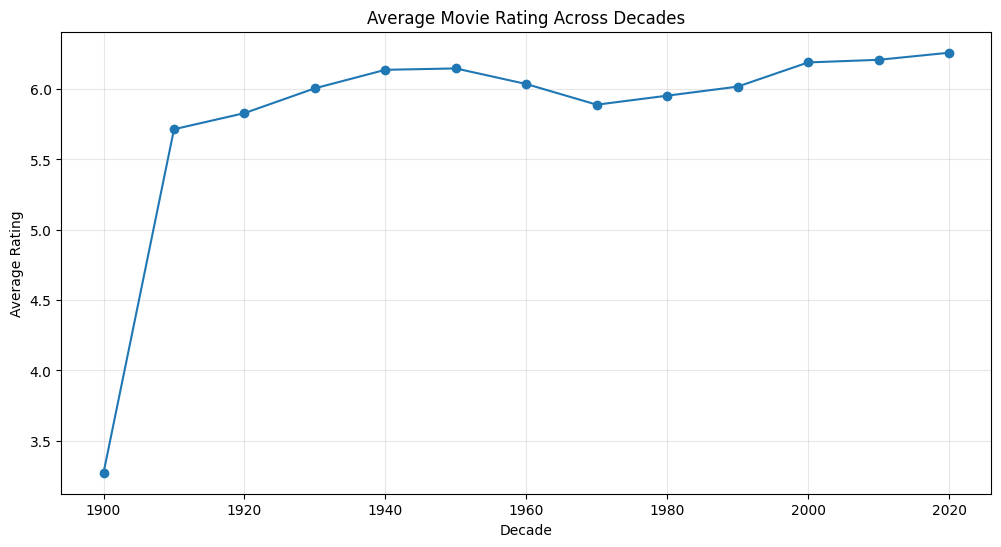

In [42]:
plt.figure(figsize=(12, 6))

plt.plot(
    decade_ratings["decade"],
    decade_ratings["average_rating"],
    marker="o"
)
plt.title("Average Movie Rating Across Decades")
plt.xlabel("Decade")
plt.ylabel("Average Rating")

plt.grid(alpha=0.3)
plt.show()

In [43]:
highest_rated_decade = decade_ratings.loc[
    decade_ratings["average_rating"].idxmax()
]

lowest_rated_decade = decade_ratings.loc[
    decade_ratings["average_rating"].idxmin()
]

print("Highest Rated Decade:")
display(highest_rated_decade)

print("Lowest Rated Decade:")
display(lowest_rated_decade)

Highest Rated Decade:


decade            2020.000000
average_rating       6.258112
Name: 12, dtype: float64

Lowest Rated Decade:


decade            1900.000000
average_rating       3.273585
Name: 0, dtype: float64

### Key Insight

Average movie ratings generally increased over the decades. The average rating was lowest in the 1900s at approximately 3.27 and reached its highest level in the 2020s at approximately 6.26. Although some fluctuations occurred between decades, the overall trend suggests a gradual increase in average movie ratings over time.

## 9. Genre vs. Rating

This section compares average movie ratings across different genres to identify which genres tend to receive higher or lower audience ratings.

In [46]:
display(genre_df.columns)
display(genre_df.head())

Index(['primaryTitle', 'year', 'decade', 'genre'], dtype='object')

,primaryTitle,year,decade,genre
0,The Story of the Kelly Gang,1906,1900,Action
0,The Story of the Kelly Gang,1906,1900,Adventure
0,The Story of the Kelly Gang,1906,1900,Biography
1,The Prodigal Son,1907,1900,Drama
2,Robbery Under Arms,1907,1900,Drama


In [47]:
genre_ratings = (
    genre_df
    .merge(
        df[["primaryTitle", "averageRating"]],
        on="primaryTitle",
        how="inner"
    )
    .groupby("genre")["averageRating"]
    .mean()
    .reset_index()
)

genre_ratings.columns = ["genre", "average_rating"]

display(
    genre_ratings.sort_values(
        "average_rating",
        ascending=False
    )
)

,genre,average_rating
12,Game-Show,7.433333
18,News,6.809463
7,Documentary,6.808405
4,Biography,6.668005
15,Music,6.600642
13,History,6.557853
23,Talk-Show,6.492105
22,Sport,6.445177
19,Reality-TV,6.390476
25,War,6.280463


### Average Rating by Genre

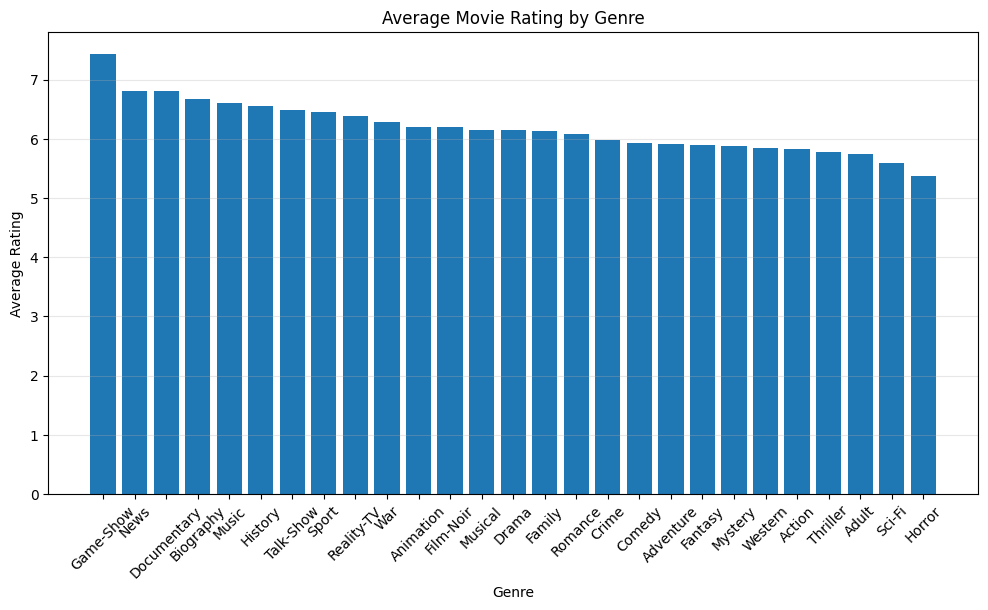

In [48]:
plt.figure(figsize=(12, 6))
sorted_genre_ratings = genre_ratings.sort_values(
    "average_rating",
    ascending=False
)
plt.bar(
    sorted_genre_ratings["genre"],
    sorted_genre_ratings["average_rating"]
)
plt.title("Average Movie Rating by Genre")
plt.xlabel("Genre")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.show()

### Key Insight

Game-Show has the highest average rating at approximately 7.43, followed by News and Documentary at around 6.8. Horror has the lowest average rating at approximately 5.38, while Thriller and Action also have relatively lower ratings. Overall, the results show noticeable differences in audience ratings across movie genres.

## 10. Genre vs. Number of Votes

This section analyzes the total number of audience votes received by different movie genres. It helps identify which genres attract greater audience engagement and popularity.

In [49]:
genre_votes = (
    genre_df
    .merge(
        df[["primaryTitle", "numVotes"]],
        on="primaryTitle",
        how="inner"
    )
    .groupby("genre")["numVotes"]
    .sum()
    .reset_index()
)
genre_votes.columns = ["genre", "total_votes"]
display(
    genre_votes.sort_values(
        "total_votes",
        ascending=False
    )
)

,genre,total_votes
8,Drama,1.490947e+09
5,Comedy,6.242221e+08
0,Action,6.116694e+08
2,Adventure,4.527926e+08
24,Thriller,4.366252e+08
6,Crime,4.163162e+08
20,Romance,3.188301e+08
14,Horror,2.946692e+08
17,Mystery,2.299586e+08
21,Sci-Fi,2.142230e+08


### Total Audience Votes by Genre

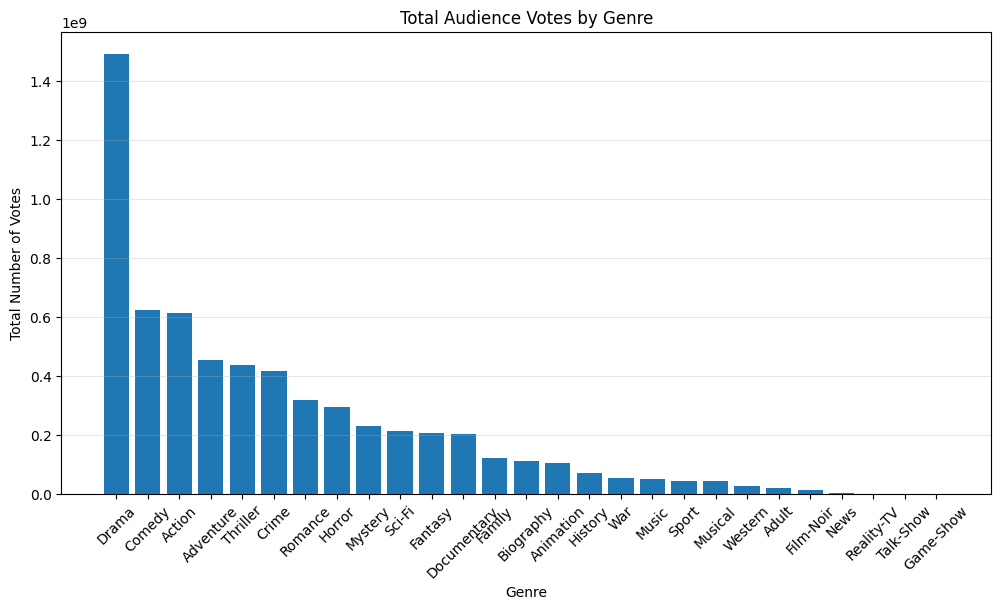

In [50]:
plt.figure(figsize=(12, 6))
sorted_genre_votes = genre_votes.sort_values(
    "total_votes",
    ascending=False
)

plt.bar(
    sorted_genre_votes["genre"],
    sorted_genre_votes["total_votes"]
)

plt.title("Total Audience Votes by Genre")
plt.xlabel("Genre")
plt.ylabel("Total Number of Votes")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.show()

In [51]:
most_voted_genre = genre_votes.loc[
    genre_votes["total_votes"].idxmax()
]

least_voted_genre = genre_votes.loc[
    genre_votes["total_votes"].idxmin()
]

print("Most Voted Genre:")
display(most_voted_genre)

print("Least Voted Genre:")
display(least_voted_genre)

Most Voted Genre:


genre                 Drama
total_votes    1490946747.0
Name: 8, dtype: object

Least Voted Genre:


genre          Game-Show
total_votes        412.0
Name: 12, dtype: object

### Key Insight

Drama receives the highest total number of audience votes, followed by Comedy and Action. This indicates that Drama movies have generated the greatest overall audience engagement in the dataset. Genres such as Reality-TV, Talk-Show, and Game-Show receive substantially fewer votes.

## 11. Top-Rated Movies

This section identifies the highest-rated movies in the dataset and examines their audience ratings and voting activity.

In [59]:
top_rated_movies = (
    df[
        ["primaryTitle", "year", "averageRating", "numVotes"]
    ]
    .dropna(subset=["averageRating"])
    .sort_values(
        "averageRating",
        ascending=False
    )
    .head(20)
)

display(top_rated_movies)

,primaryTitle,year,averageRating,numVotes
369350,Silencio,2023,10.0,6.0
535112,Riding for Jesus,2011,10.0,7.0
478173,Copps,2026,10.0,8.0
479134,"La Reina, el Buda y Buñuel",2026,10.0,9.0
165527,Sa bulaklak ng apoy,1984,10.0,6.0
457272,Better Call Pops (Preach),2025,10.0,8.0
444300,My boyfriends daddy is my man,2022,10.0,7.0
424802,Monster Metaverse: Monster Hunter Academy,2024,10.0,6.0
387039,Ifediche,2023,10.0,7.0
401564,Hoop Like This,2026,10.0,7.0


In [61]:
top_rated_reliable = (
    df[
        (df["numVotes"] >= 1000) &
        (df["averageRating"].notna())
    ]
    [
        ["primaryTitle", "year", "averageRating", "numVotes"]
    ]
    .sort_values(
        "averageRating",
        ascending=False
    )
    .head(20)
)

display(top_rated_reliable)

,primaryTitle,year,averageRating,numVotes
459767,Vinara O Vema,2026,9.6,1157.0
478465,Oka Court Case,2026,9.6,2024.0
458994,The Great Punjab Robbery,2026,9.6,1725.0
480388,Panchali Panchabhartruka,2026,9.6,2094.0
446055,Father's Day,2026,9.5,1014.0
481022,Yamudu,2026,9.4,1532.0
402560,Golden Opulence: 500 Years of Luxury in Anatolia,2024,9.4,1783.0
480302,Amma Naaku aa Abbayi Kaavaali,2026,9.4,1937.0
274054,Unpaarvayil,2025,9.4,10020.0
449323,Vidhrohi,2025,9.4,2099.0


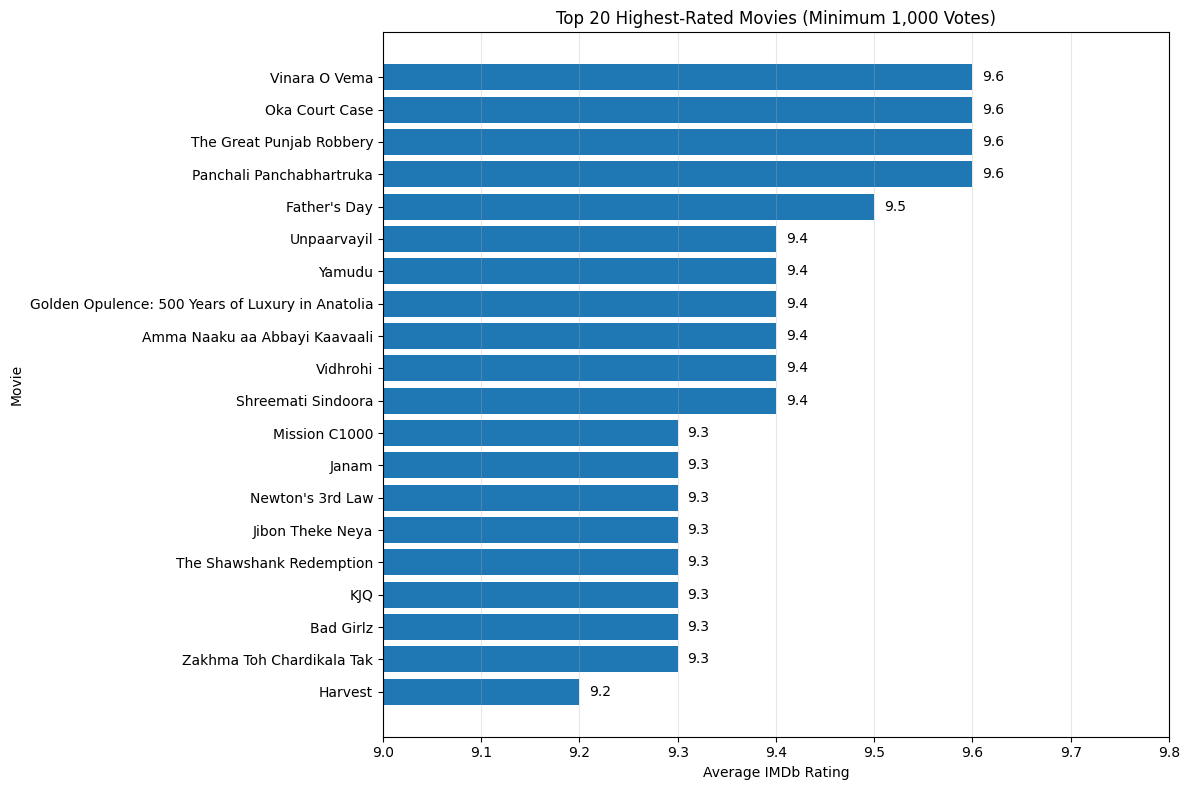

In [63]:
plt.figure(figsize=(12, 8))

top_rated_plot = top_rated_reliable.sort_values(
    "averageRating",
    ascending=True
)

bars = plt.barh(
    top_rated_plot["primaryTitle"],
    top_rated_plot["averageRating"]
)

plt.title("Top 20 Highest-Rated Movies (Minimum 1,000 Votes)")
plt.xlabel("Average IMDb Rating")
plt.ylabel("Movie")

# Focus on the actual rating range
min_rating = top_rated_plot["averageRating"].min()
max_rating = top_rated_plot["averageRating"].max()

plt.xlim(
    max(0, min_rating - 0.2),
    min(10, max_rating + 0.2)
)

# Add rating values
for bar, rating in zip(bars, top_rated_plot["averageRating"]):
    plt.text(
        bar.get_width() + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{rating:.1f}",
        va="center"
    )

plt.grid(axis="x", alpha=0.3)
plt.tight_layout()

plt.show()

### Key Insight

The highest-rated movies can have exceptionally high ratings, but rating alone does not necessarily represent broad audience consensus. Some highly-rated movies may have relatively few votes. Applying a minimum vote threshold provides a more reliable comparison by focusing on movies with greater audience participation.

## 12. Most-Voted / Popular Movies

This section identifies the movies with the highest number of IMDb votes. The number of votes is used as a measure of audience engagement and popularity.

In [64]:
most_voted_movies = (
    df[
        ["primaryTitle", "year", "averageRating", "numVotes"]
    ]
    .dropna(subset=["numVotes"])
    .sort_values(
        "numVotes",
        ascending=False
    )
    .head(20)
)

display(most_voted_movies)

,primaryTitle,year,averageRating,numVotes
71995,The Shawshank Redemption,1994,9.3,3226746.0
176700,The Dark Knight,2008,9.1,3214202.0
251282,Inception,2010,8.8,2857890.0
84276,Fight Club,1999,8.8,2650453.0
185202,Interstellar,2014,8.7,2591902.0
71250,Forrest Gump,1994,8.8,2526169.0
71848,Pulp Fiction,1994,8.8,2460210.0
82467,The Matrix,1999,8.7,2270797.0
46453,The Godfather,1972,9.2,2248906.0
76765,The Lord of the Rings: The Fellowship of the Ring,2001,8.9,2229796.0


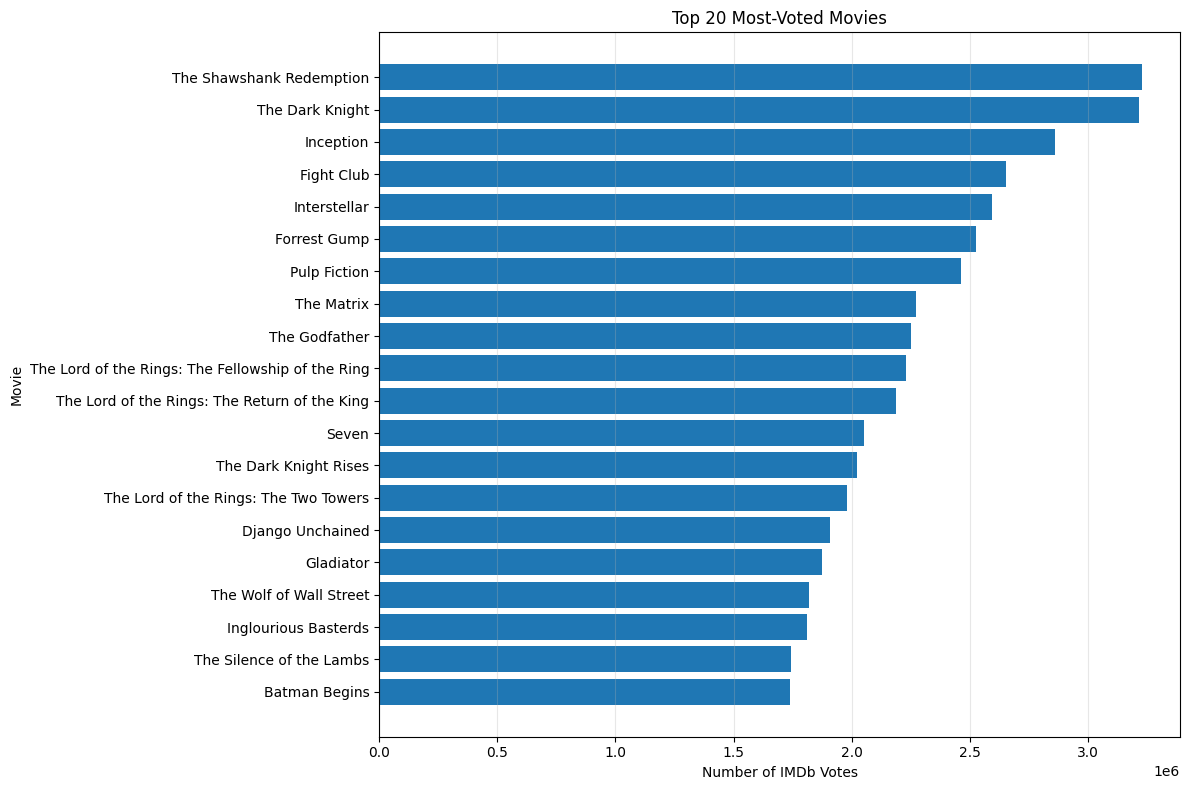

In [65]:
plt.figure(figsize=(12, 8))

most_voted_plot = most_voted_movies.sort_values(
    "numVotes",
    ascending=True
)

bars = plt.barh(
    most_voted_plot["primaryTitle"],
    most_voted_plot["numVotes"]
)

plt.title("Top 20 Most-Voted Movies")
plt.xlabel("Number of IMDb Votes")
plt.ylabel("Movie")

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()

plt.show()

In [66]:
most_voted_movies[
    [
        "primaryTitle",
        "year",
        "averageRating",
        "numVotes"
    ]
]

,primaryTitle,year,averageRating,numVotes
71995,The Shawshank Redemption,1994,9.3,3226746.0
176700,The Dark Knight,2008,9.1,3214202.0
251282,Inception,2010,8.8,2857890.0
84276,Fight Club,1999,8.8,2650453.0
185202,Interstellar,2014,8.7,2591902.0
71250,Forrest Gump,1994,8.8,2526169.0
71848,Pulp Fiction,1994,8.8,2460210.0
82467,The Matrix,1999,8.7,2270797.0
46453,The Godfather,1972,9.2,2248906.0
76765,The Lord of the Rings: The Fellowship of the Ring,2001,8.9,2229796.0


In [67]:
most_voted_movie = most_voted_movies.iloc[0]

print("Most-Voted Movie:")
display(most_voted_movie)

Most-Voted Movie:


primaryTitle     The Shawshank Redemption
year                                 1994
averageRating                         9.3
numVotes                        3226746.0
Name: 71995, dtype: object

### Key Insight

The most-voted movies represent the titles with the highest level of audience engagement in the dataset. These movies generally have very large numbers of IMDb votes, indicating broad audience reach and visibility. Comparing their ratings with vote counts also shows that high popularity does not necessarily imply the highest possible rating.

## 13. Genre Production Trends Over Time

This section analyzes how the number of movies produced in different genres has changed across decades. It helps identify which genres have grown, declined, or remained consistently popular over time.

In [52]:
genre_decade_counts = (
    genre_df
    .groupby(["decade", "genre"])
    .size()
    .reset_index(name="movie_count")
)
display(genre_decade_counts.head())

,decade,genre,movie_count
0,1900,Action,2
1,1900,Adventure,3
2,1900,Biography,4
3,1900,Comedy,6
4,1900,Documentary,71


In [53]:
top_genres = (
    genre_decade_counts
    .groupby("genre")["movie_count"]
    .sum()
    .sort_values(ascending=False)
    .head(6)
    .index
)
genre_trend = genre_decade_counts[
    genre_decade_counts["genre"].isin(top_genres)
]

display(genre_trend.head())

,decade,genre,movie_count
0,1900,Action,2
3,1900,Comedy,6
4,1900,Documentary,71
5,1900,Drama,20
13,1900,Romance,1


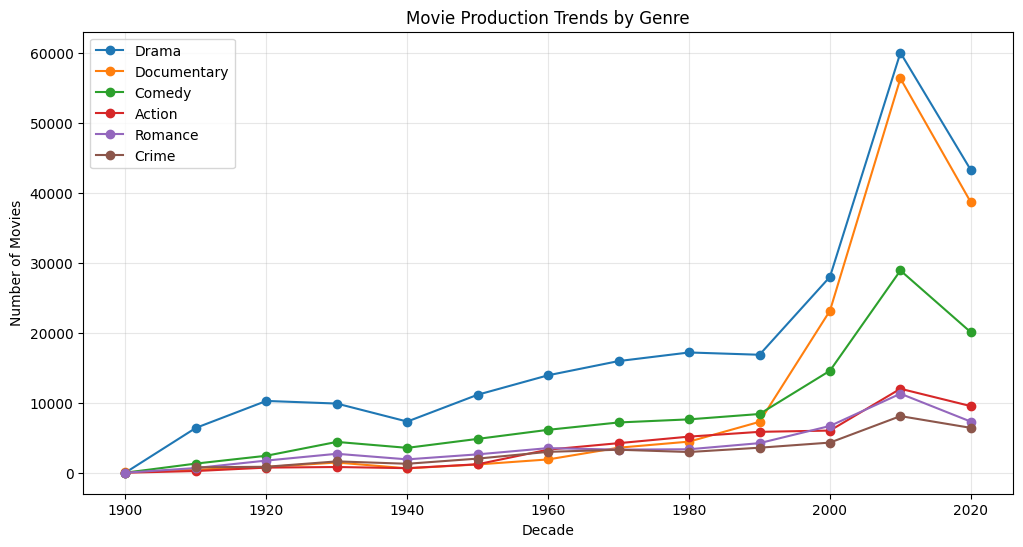

In [54]:
plt.figure(figsize=(12, 6))
for genre in top_genres:
    genre_data = genre_trend[genre_trend["genre"] == genre]
    
    plt.plot(
        genre_data["decade"],
        genre_data["movie_count"],
        marker="o",
        label=genre
    )
plt.title("Movie Production Trends by Genre")
plt.xlabel("Decade")
plt.ylabel("Number of Movies")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### Key Insight

Drama has remained the most consistently produced genre across the decades, with a substantial increase in production after 2000. Documentary and Comedy also show strong long-term growth, while Action, Romance, and Crime experienced notable increases in recent decades. Overall, movie production across major genres expanded significantly over time, with the highest production levels occurring around the 2010s.

## 14. Genre Popularity Evolution Over Time

This section analyzes how average audience ratings for different movie genres have changed across decades. It helps identify which genres have gained or lost audience appreciation over time.

In [56]:
genre_decade_ratings = (
    genre_df
    .merge(
        df[["primaryTitle", "averageRating"]],
        on="primaryTitle",
        how="inner"
    )
    .groupby(["decade", "genre"])["averageRating"]
    .mean()
    .reset_index(name="average_rating")
)

display(genre_decade_ratings.head())

,decade,genre,average_rating
0,1900,Action,4.600000
1,1900,Adventure,4.366667
2,1900,Biography,6.075000
3,1900,Comedy,3.133333
4,1900,Documentary,3.078082


In [57]:
top_rating_genres = (
    genre_decade_ratings
    .groupby("genre")["average_rating"]
    .mean()
    .sort_values(ascending=False)
    .head(6)
    .index
)

genre_rating_trend = genre_decade_ratings[
    genre_decade_ratings["genre"].isin(top_rating_genres)
]

display(genre_rating_trend.head())

,decade,genre,average_rating
2,1900,Biography,6.075000
4,1900,Documentary,3.078082
10,1900,Music,5.720000
19,1910,Biography,6.055556
22,1910,Documentary,6.105479


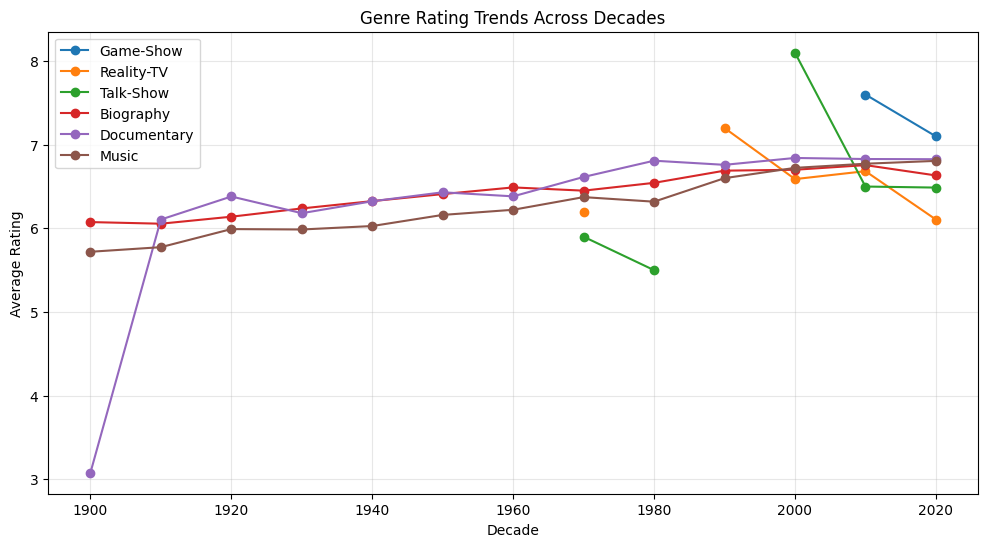

In [58]:
plt.figure(figsize=(12, 6))

for genre in top_rating_genres:
    genre_data = genre_rating_trend[
        genre_rating_trend["genre"] == genre
    ]
    
    plt.plot(
        genre_data["decade"],
        genre_data["average_rating"],
        marker="o",
        label=genre
    )

plt.title("Genre Rating Trends Across Decades")
plt.xlabel("Decade")
plt.ylabel("Average Rating")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### Key Insight

Genre ratings show different patterns across decades. Biography, Documentary, and Music maintain relatively stable and strong audience ratings over time, while some newer genres such as Game-Show, Reality-TV, and Talk-Show show more variation. Documentary ratings improve substantially compared with the early decades. Overall, audience appreciation for established genres remains relatively consistent, while newer or less frequently represented genres exhibit greater fluctuations.

# 15. Final EDA Summary / Overall Insights

This section summarizes the major findings obtained from the exploratory analysis of the IMDb movie dataset. The analysis focused on movie production, genre distribution, genre evolution, ratings, audience engagement, and popularity across different periods of cinema history.

### Dataset Overview

- The feature-engineered dataset contains **569,655 movies and 46 columns**.
- The dataset covers movies across multiple decades, beginning in the early 1900s and extending into the 2020s.
- Approximately **40.72% of movies do not have IMDb rating and vote information** in the integrated dataset.
- Approximately **22.51% of movies have missing runtime information**.
- Movies can contain multiple genres, so genre-level counts are not mutually exclusive.

### Movie Production Trends

- Movie production increased substantially across the history represented in the dataset.
- The **2010s had the highest number of movies, with 162,838 titles**.
- Production increased particularly strongly after the 2000s.
- The 2020s contain **127,635 movies**, but this should not be directly compared with complete decades because the 2020s are a partial decade in the dataset.

### Genre Findings

- **Drama** is the most represented genre in the dataset and remained highly prevalent across different decades.
- Comedy, Documentary, Action, Romance, and Crime are also major genres in terms of movie production.
- Genre production increased substantially during the later decades.
- Genre combinations are common because a single movie can belong to multiple genres.

### Rating Findings

- The mean movie rating is approximately **6.13**, while the median is approximately **6.20**.
- Most movie ratings are concentrated around the **5–8 range**, with ratings around 6–7 being particularly common.
- Average ratings varied across decades, with the lowest average observed in the **1900s (~3.27)** and the highest in the **2020s (~6.26)**.
- Genre-level analysis showed noticeable differences in average ratings between genres.

### Audience Engagement and Popularity

- The number of IMDb votes is highly skewed: the median number of votes is **69**, compared with a mean of approximately **3,822**.
- The most-voted movie in the dataset has more than **3.2 million votes**.
- **Drama** has the highest total number of audience votes among the analyzed genres, with approximately **1.49 billion total votes**.
- The correlation between average rating and number of votes is approximately **0.063**, indicating a very weak linear relationship.
- Therefore, movies receiving more votes are not necessarily rated substantially higher.

### Genre Evolution

- Genre production patterns changed considerably across decades.
- Drama remained consistently prominent throughout the analyzed period.
- Documentary, Comedy, Action, Romance, and Crime showed substantial increases in production during later decades.
- Genre rating trends also varied across decades, with some genres showing relatively stable ratings while others experienced greater fluctuations.

### Limitations

- The 2020s represent a partial decade and therefore should be interpreted carefully.
- A substantial portion of movies lack IMDb rating and vote information.
- Because movies can have multiple genres, genre counts and genre-level vote totals are not mutually exclusive.
- Total genre votes may count the same movie's votes under multiple genre categories when a movie has multiple genres.
- The correlation between ratings and votes measures linear association and does not imply causation.
- Genre-level averages can be influenced by differences in the number of movies available within each genre.

## Final Conclusion

The exploratory analysis reveals substantial changes in movie production, genre composition, audience ratings, and audience engagement throughout the history represented in the IMDb dataset. Movie production expanded considerably over time, reaching its highest level in the 2010s. Drama remained one of the most consistently represented genres, while several other genres experienced strong growth during the later decades.

Movie ratings were generally concentrated around the middle-to-upper range, with noticeable differences across genres and decades. At the same time, the very weak correlation between average rating and number of votes indicates that audience engagement and rating are largely independent in terms of their linear relationship.

These findings provide the foundation for the next stage of the Movie Genre Evolution Analyzer, where genre trends can be analyzed statistically and presented through interactive visualizations.